# Modelo Preditivo — Risco de Defasagem Acadêmica
## Datathon Passos Mágicos · Fase 5 POSTECH FIAP

O objetivo deste notebook é construir um modelo de Machine Learning capaz de
identificar, com antecedência, quais alunos apresentam risco de defasagem
educacional — ou seja, alunos cujo nível de aprendizado está abaixo do
esperado para sua faixa etária/fase.

A variável-alvo (`risco`) é derivada da coluna `Defasagem` da base PEDE:
- `risco = 1` → aluno com defasagem negativa (está atrás do nível esperado)
- `risco = 0` → aluno sem defasagem

O modelo permite que a equipe da Passos Mágicos realize intervenções precoces,
priorizando atenção aos alunos mais vulneráveis antes que a defasagem se agrave.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil, os
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score, f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

## 1. Carregamento e Preparação dos Dados

A base de dados PEDE está dividida em três abas no mesmo arquivo Excel,
uma por ano (2022, 2023, 2024). Cada aba usa nomes de colunas ligeiramente
diferentes — por exemplo, o INDE aparece como "INDE 22", "INDE 2023" e
"INDE 2024" dependendo do ano.

**Por que padronizar?**  
Para concatenar os três anos em um único DataFrame, todas as colunas
precisam ter o mesmo nome. Criamos um dicionário de renomeação para
cada ano e, ao final, selecionamos apenas as colunas comuns.

**Por que usar `shutil.copy2` antes de ler o Excel?**  
O arquivo original pode estar bloqueado pelo sistema de arquivos (ex: aberto
no Excel). A cópia temporária evita o `PermissionError` durante a leitura.

**Por que `dropna(subset=['IDA', 'IEG'])`?**  
Registros sem as features principais de desempenho e engajamento são
pouco informativos para o modelo. Removê-los evita imputações excessivas
sem sacrificar volume significativo de dados.

**Colunas excluídas propositalmente:**  
- `IAN` → derivação direta da variável-alvo (data leakage comprovado)
- `INDE` → índice composto que embute IAN em sua fórmula (leakage indireto)
- `Pedra` → classificação final atribuída após a avaliação do aluno (resultado, não entrada)


In [13]:
DATA_PATH = r'../BASE DE DADOS PEDE 2024 - DATATHON.xlsx'
TMP_PATH  = r'../data/processed/_tmp_pede.xlsx'
shutil.copy2(DATA_PATH, TMP_PATH)

df22 = pd.read_excel(TMP_PATH, sheet_name='PEDE2022')
df23 = pd.read_excel(TMP_PATH, sheet_name='PEDE2023')
df24 = pd.read_excel(TMP_PATH, sheet_name='PEDE2024')
os.remove(TMP_PATH)

# Padronizar 2022
rename_22 = {
    'Fase': 'Fase_num', 'Gênero': 'Genero', 'Ano ingresso': 'Ano_ingresso',
    'Instituição de ensino': 'Instituicao', 'INDE 22': 'INDE',
    'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS', 'IDA': 'IDA',
    'Matem': 'Mat', 'Portug': 'Por', 'Inglês': 'Ing', 'Idade 22': 'Idade',
    'IPV': 'IPV', 'IAN': 'IAN', 'Defas': 'Defasagem',
}
df22r = df22.rename(columns=rename_22)
df22r['Ano'] = 2022
df22r['IPP'] = np.nan
fase_map_num = {0:'ALFA',1:'FASE 1',2:'FASE 2',3:'FASE 3',
                4:'FASE 4',5:'FASE 5',6:'FASE 6',7:'FASE 7'}
df22r['Fase'] = df22r['Fase_num'].map(fase_map_num)
df22r['Genero'] = df22r['Genero'].map({'Menina':'Feminino','Menino':'Masculino'})

# Padronizar 2023
rename_23 = {
    'Fase':'Fase', 'Gênero':'Genero', 'Ano ingresso':'Ano_ingresso',
    'Instituição de ensino':'Instituicao', 'INDE 2023':'INDE',
    'IAA':'IAA', 'IEG':'IEG', 'IPS':'IPS', 'IPP':'IPP', 'IDA':'IDA',
    'Mat':'Mat', 'Por':'Por', 'Ing':'Ing', 'Idade':'Idade',
    'IPV':'IPV', 'IAN':'IAN', 'Defasagem':'Defasagem',
}
df23r = df23.rename(columns=rename_23)
df23r['Ano'] = 2023
df23r['Idade'] = pd.to_numeric(df23r['Idade'], errors='coerce')

# Padronizar 2024
rename_24 = dict(rename_23)
rename_24.update({'INDE 2024':'INDE'})
df24r = df24.rename(columns=rename_24)
df24r['Ano'] = 2024
df24r['INDE'] = pd.to_numeric(df24r['INDE'], errors='coerce')

# Consolidar — INDE, IAN e Pedra excluídos da lista de colunas finais
cols = ['RA','Ano','Fase','Genero','Idade','Ano_ingresso',
        'IAA','IEG','IPS','IPP','IDA','Mat','Por','Ing','IPV','Defasagem']
for c in cols:
    for d in [df22r, df23r, df24r]:
        if c not in d.columns:
            d[c] = np.nan

df = pd.concat([df22r[cols], df23r[cols], df24r[cols]], ignore_index=True)
for c in ['IAA','IEG','IPS','IPP','IDA','Mat','Por','Ing','IPV','Defasagem','Idade']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Manter apenas registros com ao menos a maioria das features preenchidas
df = df.dropna(subset=['IDA', 'IEG'])
print(f"Dataset consolidado: {df.shape}")

Dataset consolidado: (2852, 16)


## 2. Feature Engineering

### Variável-alvo: `risco`
Criada a partir de `Defasagem < 0`. O sinal negativo indica que o aluno está
abaixo do nível esperado. Usar a defasagem bruta como target de regressão
seria mais complexo e menos interpretável; a binarização em "em risco / sem risco"
é direta e alinhada com a tomada de decisão da equipe pedagógica.

### Por que estas features e não outras?

A regra de ouro de Machine Learning é: **só usar como feature informações que
existiriam antes de saber o resultado**. As features escolhidas são observadas
ao longo do processo educativo (durante o ano letivo), e não dependem do resultado
final de defasagem:

| Feature | O que representa | Por que é válida |
|---------|-----------------|-----------------|
| `IAA` | Autoavaliação do aluno | Percepção subjetiva do próprio desempenho |
| `IEG` | Engajamento | Frequência e participação nas atividades |
| `IPS` | Indicador psicossocial | Contexto socioemocional do aluno |
| `IPP` | Indicador psicopedagógico | Avaliação do acompanhamento pedagógico |
| `IDA` | Desempenho acadêmico | Notas e avaliações durante o período |
| `IPV` | Ponto de Virada | Indicador motivacional / transformação pessoal |
| `Mat`, `Por`, `Ing` | Notas das disciplinas | Desempenho objetivo por área |
| `Idade` | Idade do aluno | Importante para contextualizar defasagem etária |
| `Genero_enc` | Gênero (codificado) | Fator demográfico |
| `Tempo_inst` | Anos na instituição | Alunos mais antigos tendem a ter trajetória diferente |
| `Fase_enc` | Fase escolar (ordinal) | Nível de avanço no programa |

### Codificação de variáveis categóricas
- `Genero` → `LabelEncoder` (binário: 0=Feminino, 1=Masculino)
- `Fase` → mapeamento ordinal (ALFA=0, FASE 1=1, ..., FASE 8=8), preservando a progressão natural
- `Pedra` → **excluída** (é uma consequência do INDE, que por sua vez embute IAN)

### Imputação de nulos
Valores ausentes nas features são preenchidos com a **mediana** de cada coluna.
A mediana foi escolhida por ser robusta a outliers, ao contrário da média.
O `IPP` não existia em 2022 e foi imputado inteiramente — isso reduz levemente
seu poder preditivo para aquele ano, mas mantém a consistência do dataset.

In [14]:
df['risco'] = (df['Defasagem'] < 0).astype(int)
print(f"Distribuicao do target:\n{df['risco'].value_counts()}")
print(f"Proporcao risco: {df['risco'].mean():.2%}")

Distribuicao do target:
risco
1    1684
0    1168
Name: count, dtype: int64
Proporcao risco: 59.05%


In [15]:
df['Genero_enc']  = LabelEncoder().fit_transform(df['Genero'].fillna('Desconhecido'))
df['Tempo_inst']  = df['Ano'] - df['Ano_ingresso']
fase_order = {'ALFA':0,'FASE 1':1,'FASE 2':2,'FASE 3':3,'FASE 4':4,
              'FASE 5':5,'FASE 6':6,'FASE 7':7,'FASE 8':8}
df['Fase_enc'] = df['Fase'].map(fase_order).fillna(0)

# Features limpas — sem INDE, IAN, Pedra
features = [
    'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV',   # indicadores de processo
    'Mat', 'Por', 'Ing',                           # notas das disciplinas
    'Idade', 'Genero_enc', 'Tempo_inst', 'Fase_enc'  # perfil do aluno
]
print(f"Features ({len(features)}): {features}")

Features (13): ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'Mat', 'Por', 'Ing', 'Idade', 'Genero_enc', 'Tempo_inst', 'Fase_enc']


In [16]:
df_model = df[features + ['risco']].dropna(subset=['risco']).copy()
for c in features:
    df_model[c] = df_model[c].fillna(df_model[c].median())

print(f"Dataset para modelagem: {df_model.shape}")
print(f"Distribuicao target:\n{df_model['risco'].value_counts()}")

Dataset para modelagem: (2852, 14)
Distribuicao target:
risco
1    1684
0    1168
Name: count, dtype: int64


## 3. Separação Treino/Teste

**Proporção 80/20:**  
80% dos dados são usados para treinar os modelos e 20% são reservados para
avaliação final. Esse é o padrão mais comum para datasets de tamanho médio
(~2.800 registros), equilibrando quantidade de dados para treino com uma
amostra significativa de teste.

**`stratify=y`:**  
Garante que a proporção de alunos "em risco" e "sem risco" seja a mesma
nos conjuntos de treino e teste. Sem isso, por aleatoriedade, um dos conjuntos
poderia ter proporções muito diferentes, comprometendo a validade da avaliação.

**`random_state=42`:**  
Fixa a semente aleatória para que os resultados sejam reproduzíveis.

**Padronização com `StandardScaler`:**  
Transforma cada feature para ter média 0 e desvio padrão 1. Isso é necessário
especialmente para a Regressão Logística, que é sensível à escala das variáveis.

**Atenção:** o scaler é ajustado (`fit`) **somente no treino** e apenas aplicado
(`transform`) no teste. Ajustá-lo no conjunto completo introduziria *data leakage*,
pois informações do teste contaminariam o treino.

In [17]:
X = df_model[features]
y = df_model['risco']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Proporcao risco treino: {y_train.mean():.2%}")
print(f"Proporcao risco teste:  {y_test.mean():.2%}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Treino: (2281, 13) | Teste: (571, 13)
Proporcao risco treino: 59.05%
Proporcao risco teste:  59.02%


## 4. Modelagem Preditiva

Três algoritmos foram treinados e comparados, cobrindo diferentes abordagens:

| Modelo | Característica | Vantagem |
|--------|---------------|----------|
| **Logistic Regression** | Linear, interpretável | Baseline rápido e estável |
| **Random Forest** | Ensemble de árvores (bagging) | Robusto a overfitting, captura não-linearidades |
| **Gradient Boosting** | Ensemble sequencial (boosting) | Alta acurácia em dados tabulares |

**Por que comparar múltiplos modelos?**  
Não é possível saber a priori qual algoritmo funcionará melhor para um dataset
específico. Treinar os três e selecionar o melhor com base em métricas objetivas
é uma prática padrão de ML.

**Validação cruzada estratificada (5-fold):**  
Além da avaliação no conjunto de teste fixo, aplicamos Stratified K-Fold com
5 folds no conjunto de treino. Isso serve para:
1. Estimar a variabilidade do desempenho do modelo (média ± desvio padrão do F1)
2. Detectar overfitting — se o F1 no teste fixo for muito superior ao CV, o modelo
   pode estar memorizando o treino

**Hiperparâmetros escolhidos:**
- Random Forest: `n_estimators=200` (200 árvores para estabilidade), `max_depth=10` (limita complexidade)
- Gradient Boosting: `n_estimators=200`, `max_depth=5` (árvores rasas evitam overfitting no boosting)


In [18]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5)
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='f1')

    results[name] = {
        'acc': acc, 'f1': f1, 'auc': auc,
        'cv_f1': cv_scores.mean(), 'cv_std': cv_scores.std()
    }
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC:  {auc:.4f}")
    print(f"  CV F1:    {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


Logistic Regression
  Accuracy: 0.5902
  F1-Score: 0.6913
  ROC-AUC:  0.6313
  CV F1:    0.7156 +/- 0.0139

Random Forest
  Accuracy: 0.7776
  F1-Score: 0.8291
  ROC-AUC:  0.8705
  CV F1:    0.8247 +/- 0.0055

Gradient Boosting
  Accuracy: 0.8476
  F1-Score: 0.8755
  ROC-AUC:  0.9187
  CV F1:    0.8712 +/- 0.0127


## 5. Avaliação dos Resultados

### Métricas utilizadas e por que foram escolhidas

**F1-Score** (critério de seleção do melhor modelo):  
Harmônica entre Precisão e Recall. É a métrica mais adequada quando as classes
estão desbalanceadas (~59% em risco vs. ~41% sem risco), pois penaliza tanto
falsos positivos quanto falsos negativos. Um modelo que sempre previsse "em risco"
teria recall perfeito mas F1 baixo.

**ROC-AUC:**  
Mede a capacidade discriminativa do modelo de forma independente do limiar de
classificação. Quanto mais próximo de 1.0, melhor o modelo separa as duas classes.
É útil para comparar modelos sem depender de um threshold fixo.

**Accuracy:**  
Porcentagem de previsões corretas. Menos informativa sozinha quando há
desbalanceamento de classes, mas útil em conjunto com as demais métricas.

**Matriz de Confusão:**  
Permite entender os tipos de erro do modelo:
- **Falso Negativo** (real=Em Risco, previsto=Sem Risco): o mais crítico — o modelo
  deixa de sinalizar um aluno que precisa de atenção
- **Falso Positivo** (real=Sem Risco, previsto=Em Risco): gera trabalho desnecessário
  para a equipe pedagógica, mas é menos grave

**Importância das Features:**  
Indica quais variáveis mais influenciaram as previsões do modelo.
Para Random Forest e Gradient Boosting, essa métrica é baseada na redução
média de impureza nas divisões das árvores.

### Seleção do melhor modelo
O modelo com **maior F1-Score no conjunto de teste** é automaticamente salvo.
O F1 foi escolhido como critério por ser mais robusto que a acurácia em contextos
com leve desbalanceamento de classes.

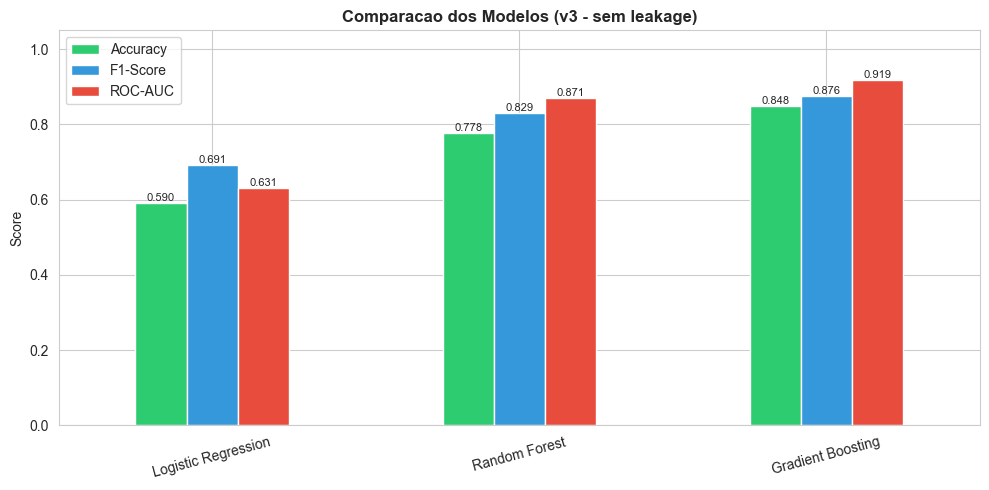

In [19]:
res_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(10, 5))
res_df[['acc', 'f1', 'auc']].plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c'])
ax.set_title('Comparacao dos Modelos (v3 - sem leakage)', fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.legend(['Accuracy', 'F1-Score', 'ROC-AUC'])
ax.tick_params(axis='x', rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/modelo_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

Melhor modelo: Gradient Boosting


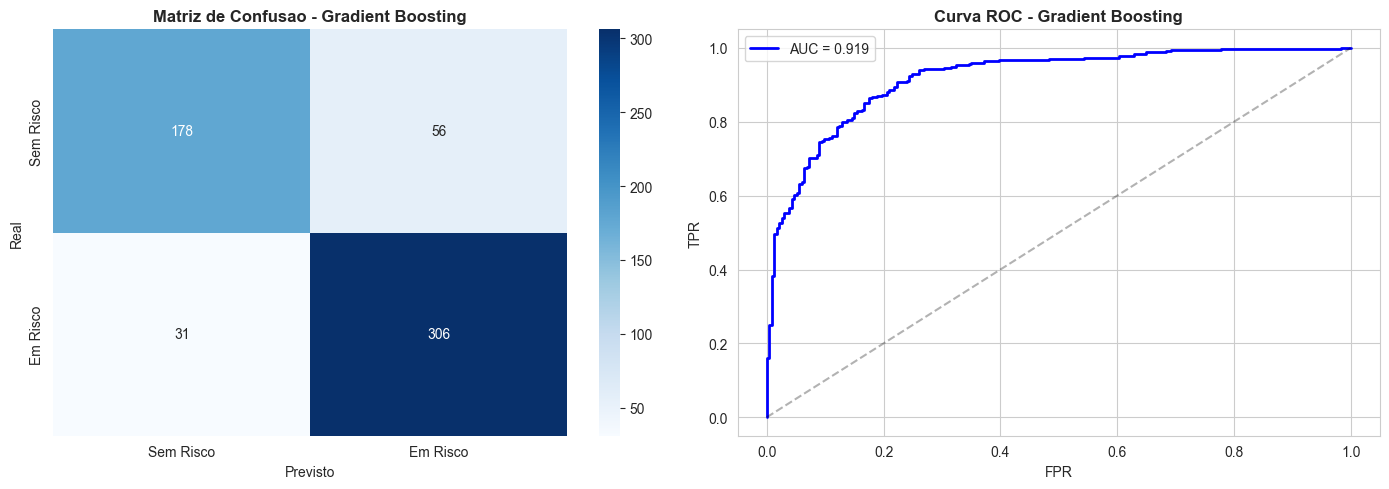


Classification Report - Gradient Boosting:
              precision    recall  f1-score   support

   Sem Risco       0.85      0.76      0.80       234
    Em Risco       0.85      0.91      0.88       337

    accuracy                           0.85       571
   macro avg       0.85      0.83      0.84       571
weighted avg       0.85      0.85      0.85       571



In [20]:
best_name  = max(results, key=lambda k: results[k]['f1'])
best_model = models[best_name]
print(f"Melhor modelo: {best_name}")

y_pred_best  = best_model.predict(X_test_s)
y_proba_best = best_model.predict_proba(X_test_s)[:, 1]

# Matriz de confusao + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sem Risco', 'Em Risco'],
            yticklabels=['Sem Risco', 'Em Risco'])
axes[0].set_title(f'Matriz de Confusao - {best_name}', fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Previsto')

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
axes[1].plot(fpr, tpr, 'b-', linewidth=2,
             label=f'AUC = {roc_auc_score(y_test, y_proba_best):.3f}')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'Curva ROC - {best_name}', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('../data/processed/modelo_avaliacao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClassification Report - {best_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Sem Risco', 'Em Risco']))

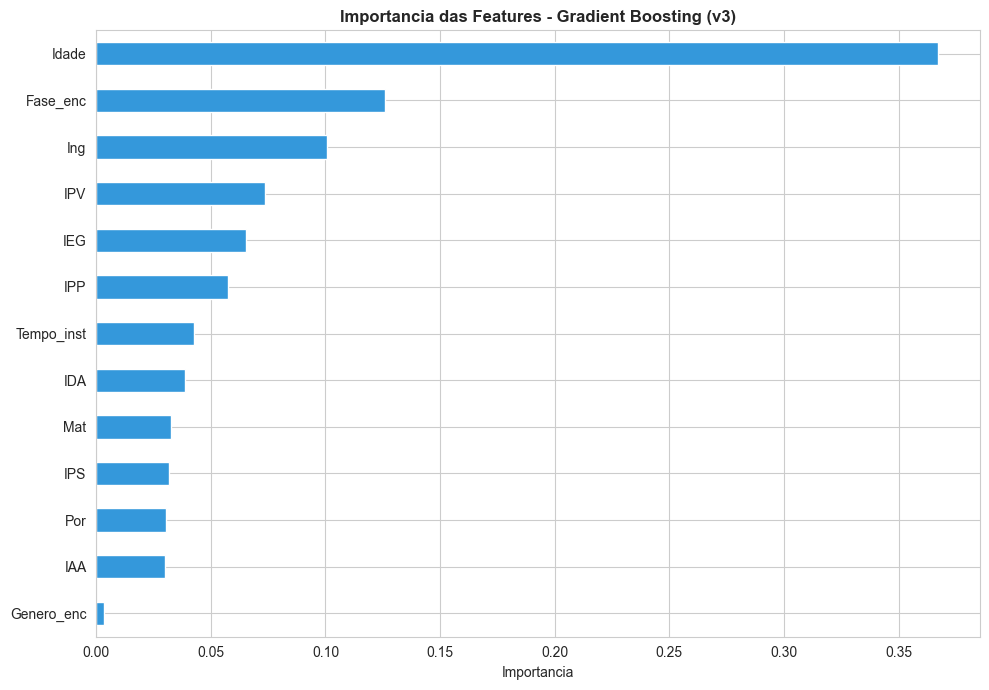

In [21]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=features).sort_values()
else:
    imp = pd.Series(np.abs(best_model.coef_[0]), index=features).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
imp.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title(f'Importancia das Features - {best_name} (v3)', fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('../data/processed/modelo_features.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultado: modelo selecionado — Gradient Boosting

O **Gradient Boosting** obteve o maior F1-Score entre os três modelos avaliados
e foi automaticamente selecionado como o modelo final.

| Modelo | Accuracy | F1-Score | ROC-AUC | CV F1 |
|--------|----------|----------|---------|-------|
| Logistic Regression | 0.5902 | 0.6913 | 0.6313 | 0.7156 ± 0.014 |
| Random Forest | 0.7776 | 0.8291 | 0.8705 | 0.8247 ± 0.006 |
| **Gradient Boosting** ✅ | **0.8476** | **0.8755** | **0.9187** | **0.8712 ± 0.013** |

**Por que o Gradient Boosting performou melhor?**  
O Gradient Boosting constrói árvores de decisão de forma sequencial, onde cada
nova árvore corrige os erros da anterior. Esse processo iterativo é especialmente
eficaz em dados tabulares com relações não-lineares entre as features — exatamente
o que temos aqui, já que indicadores educacionais como IDA, IEG e IPV interagem
entre si de forma complexa.

**Análise dos resultados:**
- **F1 = 0.88** — o modelo acerta bem em ambas as classes, sem favorecer excessivamente uma delas
- **ROC-AUC = 0.92** — excelente capacidade discriminativa; o modelo distingue bem alunos em risco dos que não estão
- **CV F1 = 0.87 ± 0.013** — baixo desvio padrão indica que o modelo é estável e generaliza bem para dados novos
- **Recall de 91% para "Em Risco"** — de cada 10 alunos realmente em risco, o modelo identifica corretamente 9. Isso é especialmente importante: minimizar os falsos negativos (alunos em risco que passam despercebidos) é a prioridade pedagógica da Passos Mágicos.

## 6. Exportação do Modelo

Três arquivos são salvos com `joblib` para uso em produção (Streamlit):

| Arquivo | Conteúdo | Para que serve |
|---------|----------|---------------|
| `modelo_risco.joblib` | Objeto do classificador treinado | Fazer as previsões |
| `scaler.joblib` | StandardScaler ajustado no treino | Padronizar inputs novos na mesma escala usada no treino |
| `features.joblib` | Lista com os 13 nomes das features | Garantir que o DataFrame de input tenha as colunas na ordem correta |

**Por que salvar o scaler separadamente?**  
Quando um usuário insere dados no Streamlit, esses dados precisam passar pela
mesma transformação de escala que foi aplicada no treino. Se o scaler não for
salvo e reutilizado, as previsões serão incorretas.

**Por que salvar a lista de features?**  
O modelo é sensível à ordem das colunas no DataFrame de entrada.
Carregar a lista de features garante que o Streamlit monte o input
exatamente na ordem esperada pelo modelo.

In [22]:
os.makedirs('../modelo', exist_ok=True)
joblib.dump(best_model, '../modelo/modelo_risco.joblib')
joblib.dump(scaler,     '../modelo/scaler.joblib')
joblib.dump(features,   '../modelo/features.joblib')
print(f"Modelo '{best_name}' salvo em modelo/modelo_risco.joblib")
print(f"Scaler salvo em modelo/scaler.joblib")
print(f"Features ({len(features)}): {features}")

Modelo 'Gradient Boosting' salvo em modelo/modelo_risco.joblib
Scaler salvo em modelo/scaler.joblib
Features (13): ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'Mat', 'Por', 'Ing', 'Idade', 'Genero_enc', 'Tempo_inst', 'Fase_enc']
